<a href="https://colab.research.google.com/github/ojaspaul123/Projects/blob/main/Flight%20Price%20Prediction/Flight_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('flight-price-analysis-and-prediction.csv')
df.head()

Saving flight-price-analysis-and-prediction.csv to flight-price-analysis-and-prediction.csv


,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45


In [3]:
df.shape

(67, 14)

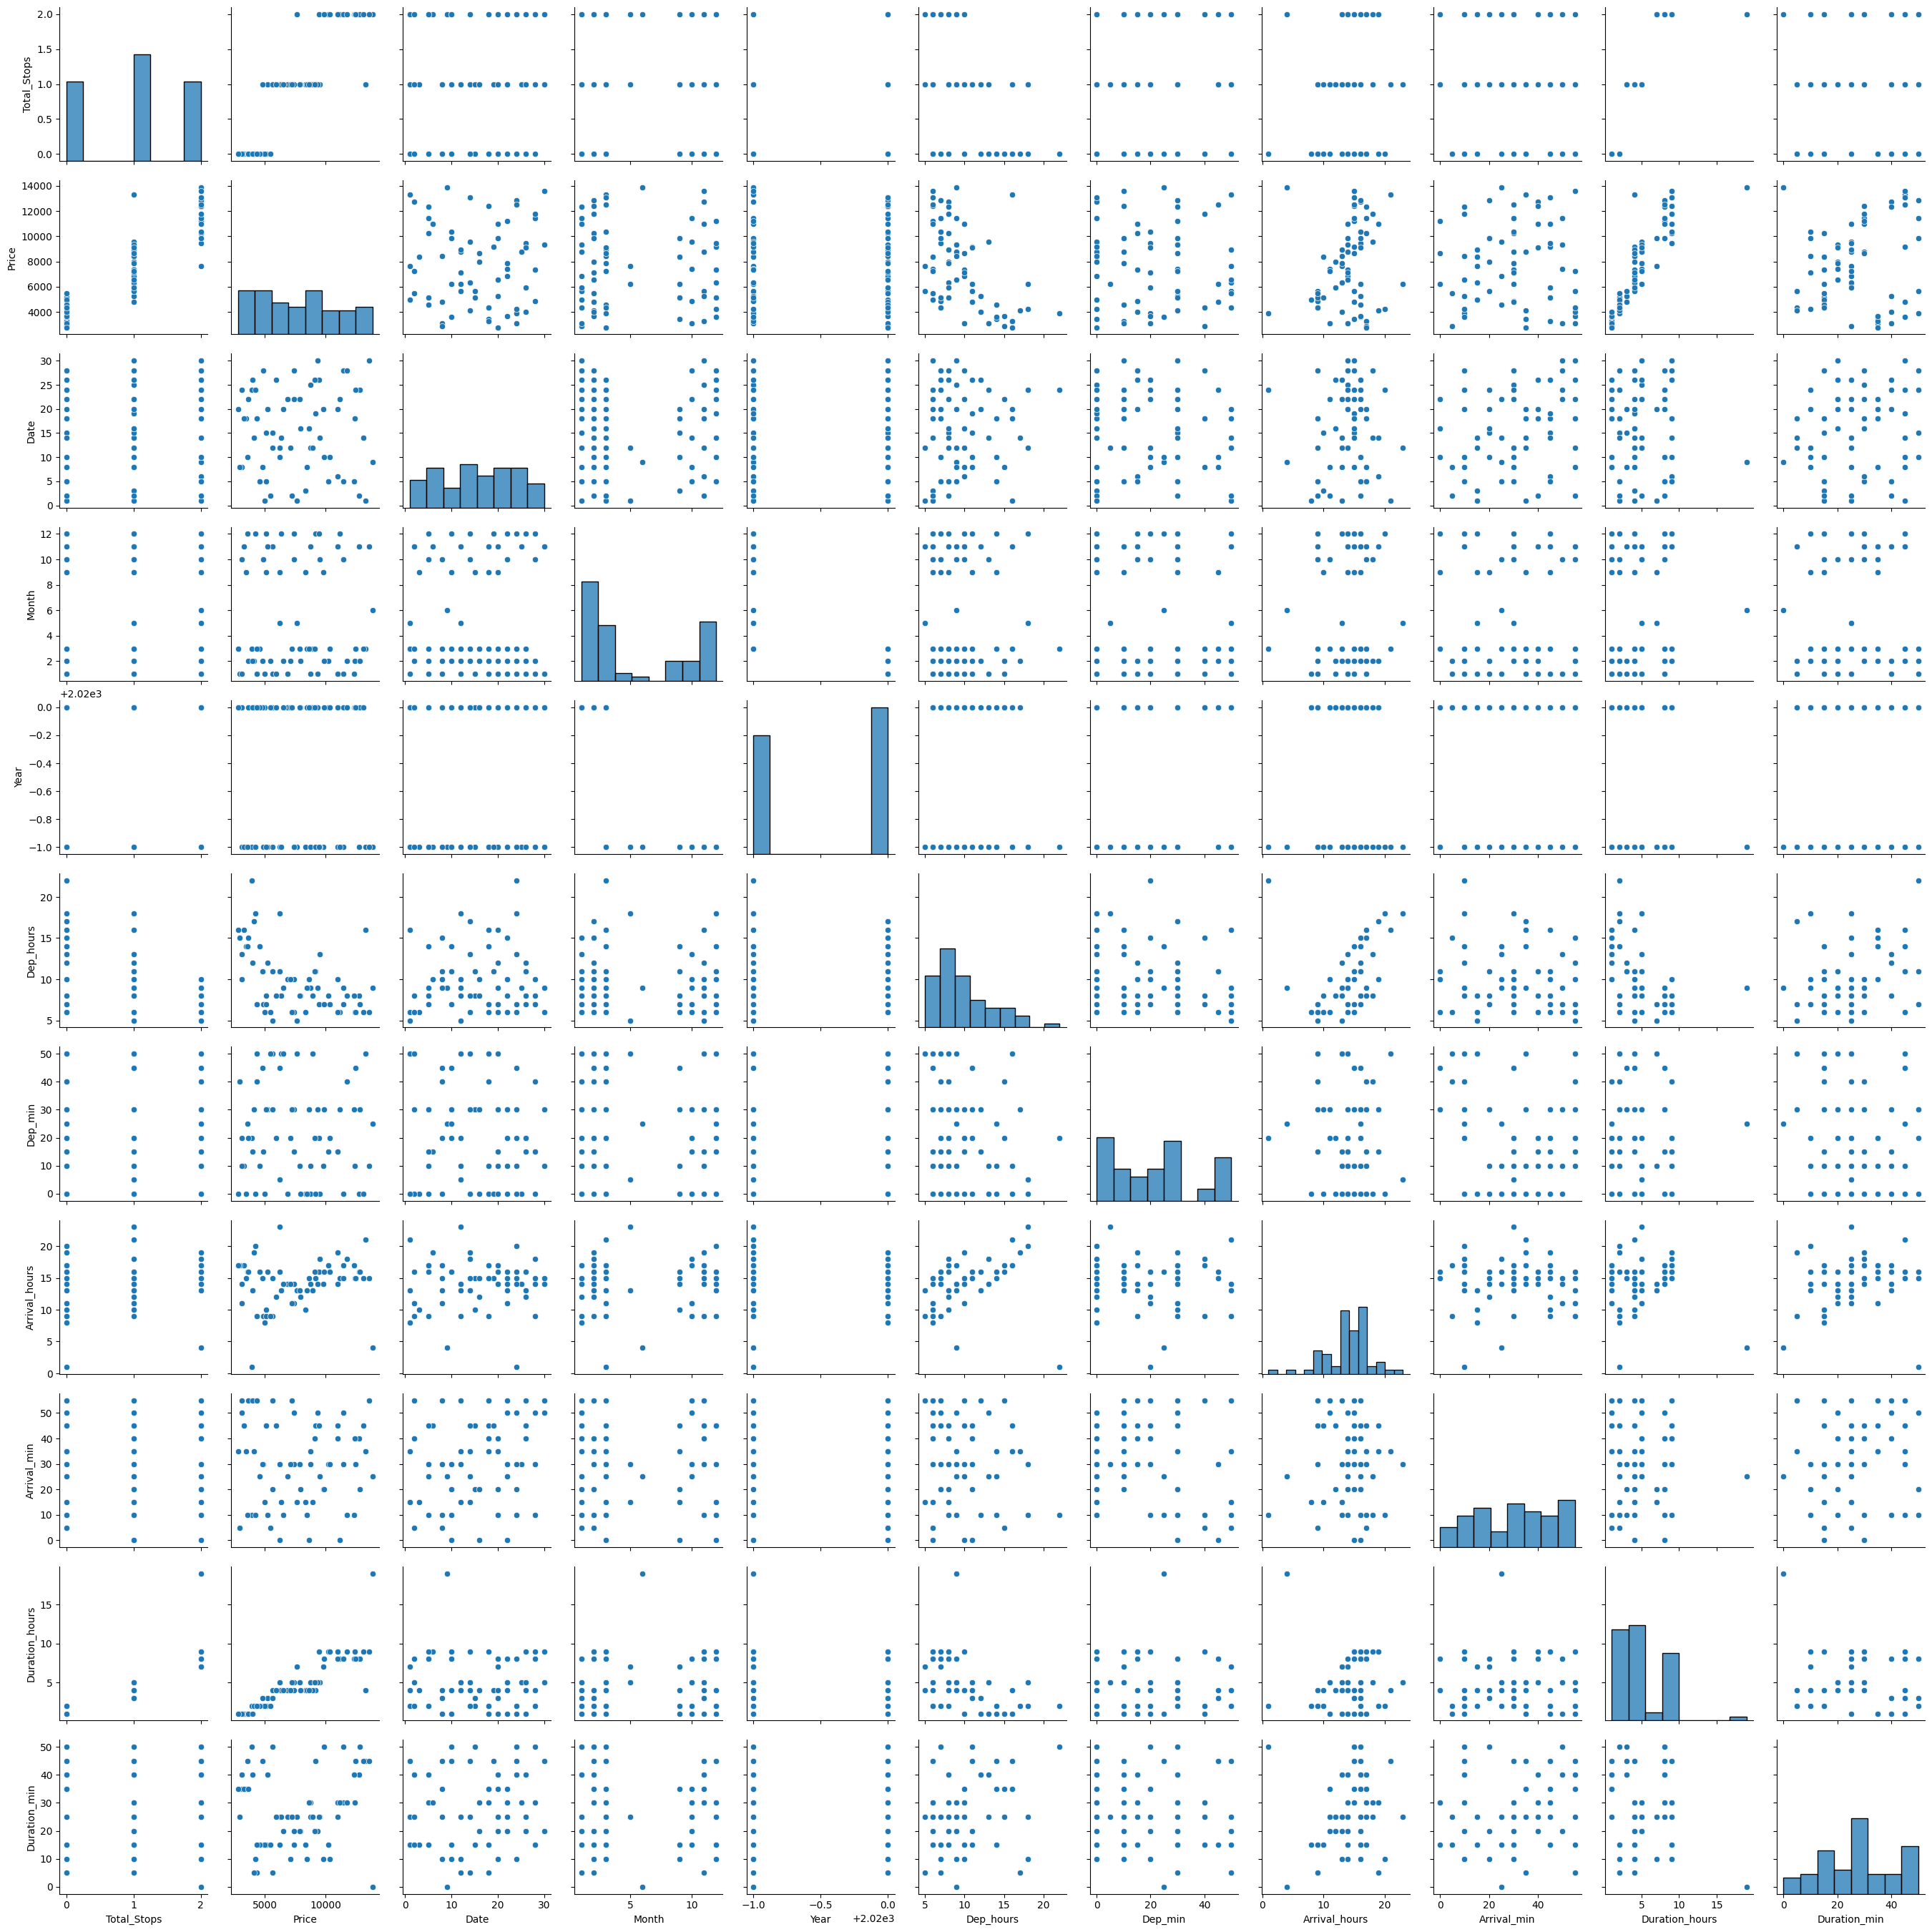

In [4]:
sns.pairplot(df)

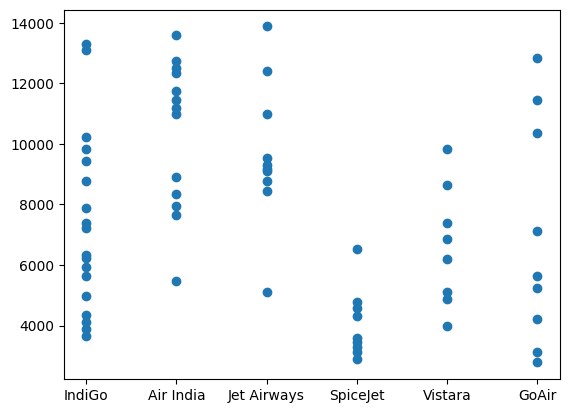

In [5]:
plt.scatter(x=df['Airline'],y=df['Price'])


In [6]:
##feature engineering
df['Full_Date'] = pd.to_datetime(
    df[['Year', 'Month', 'Date']].rename(columns={'Year':'year', 'Month':'month', 'Date':'day'})
)
df.drop(columns=['Full_Date', 'Year', 'Month', 'Date'], inplace=True)

# Separate features and target
X = df.drop(columns=['Price'])
y = df['Price']

print("Feature shape :", X.shape)
print("Target shape  :", y.shape)
print()
print(X.dtypes)

Feature shape : (67, 10)
Target shape  : (67,)

Airline           object
Source            object
Destination       object
Total_Stops        int64
Dep_hours          int64
Dep_min            int64
Arrival_hours      int64
Arrival_min        int64
Duration_hours     int64
Duration_min       int64
dtype: object


In [7]:
# Encoding Categorical Columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(include='number').columns.tolist()

print("Categorical features :", categorical_cols)
print("Numerical  features  :", numerical_cols)

Categorical features : ['Airline', 'Source', 'Destination']
Numerical  features  : ['Total_Stops', 'Dep_hours', 'Dep_min', 'Arrival_hours', 'Arrival_min', 'Duration_hours', 'Duration_min']


In [8]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
X_train.shape


Training samples : 53
Testing  samples : 14


(53, 10)

In [9]:

%%markdown
---
Creating Pipeline

---
Creating Pipeline


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                               numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',    LinearRegression()),
])

print("Pipeline architecture:")
print(pipeline)

Pipeline architecture:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Total_Stops', 'Dep_hours',
                                                   'Dep_min', 'Arrival_hours',
                                                   'Arrival_min',
                                                   'Duration_hours',
                                                   'Duration_min']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination'])])),
                ('regressor', LinearRegression())])


In [11]:
pipeline.fit(X_train, y_train)
print("✅ Pipeline trained successfully")

✅ Pipeline trained successfully


In [12]:

%%markdown
---
Encoding Pipeline

---
Encoding Pipeline


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [14]:
from sklearn.ensemble import RandomForestRegressor
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=42))
])

In [15]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination']),
                                                 ('num', 'passthrough',
                                                  ['Total_Stops', 'Dep_hours',
                                                   'Dep_min', 'Arrival_hours',
                                                   'Arrival_min',
                                                   'Duration_hours',
                                                   'Duration_min'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [16]:
preds = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 1648.586785714286


In [19]:

%%markdown
---
Accuracy Score

---
Accuracy Score


In [20]:
##Evaluate the test
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
y_pred = pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# 5-fold Cross-Validation R² on training data
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')

print("=" * 45)
print("   Linear Regression Pipeline — Results")
print("=" * 45)
print(f"  MAE          : ₹{mae:,.2f}")
print(f"  RMSE         : ₹{rmse:,.2f}")
print(f"  R² Score     : {r2:.4f}")
print(f"  CV R² (mean) : {cv_scores.mean():.4f}")
print(f"  CV R² (std)  : {cv_scores.std():.4f}")
print("=" * 45)

   Linear Regression Pipeline — Results
  MAE          : ₹1,664.39
  RMSE         : ₹3,112.74
  R² Score     : -0.2928
  CV R² (mean) : 0.9160
  CV R² (std)  : 0.0408


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [21]:
%%markdown
---
Linear Regression - Pipeline

---
Linear Regression - Pipeline


In [22]:
# Feature Coefficients
lr_model = pipeline.named_steps['regressor']
ohe      = pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_cols = ohe.get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + ohe_cols

coef_df = pd.DataFrame({
    'Feature'     : all_features,
    'Coefficient' : lr_model.coef_
}).reindex(columns=['Feature', 'Coefficient'])

coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print(f"Intercept: {lr_model.intercept_:,.2f}")
print()
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

Intercept: 6,983.74

              Feature  Coefficient
       Duration_hours  2067.012684
     Source_New Delhi  2022.604859
   Destination_Cochin  1696.854437
            Dep_hours -1494.823151
        Airline_GoAir -1364.453417
        Source_Cochin  1351.860758
        Arrival_hours  1315.528474
     Airline_SpiceJet  -902.825355
  Destination_Kolkata   869.651692
    Destination_Delhi   737.257479
   Destination_Mumbai   693.233225
       Airline_IndiGo  -666.920436
Destination_New Delhi   665.314766
Destination_Hyderabad   516.339675
        Source_Mumbai   494.648674
      Airline_Vistara  -422.019737
  Airline_Jet Airways   414.475867
     Source_Hyderabad   381.498810
         Source_Delhi   357.325286
              Dep_min  -331.037281
          Total_Stops  -205.985414
       Source_Kolkata  -187.597281
         Duration_min    86.815800
          Arrival_min     2.629384


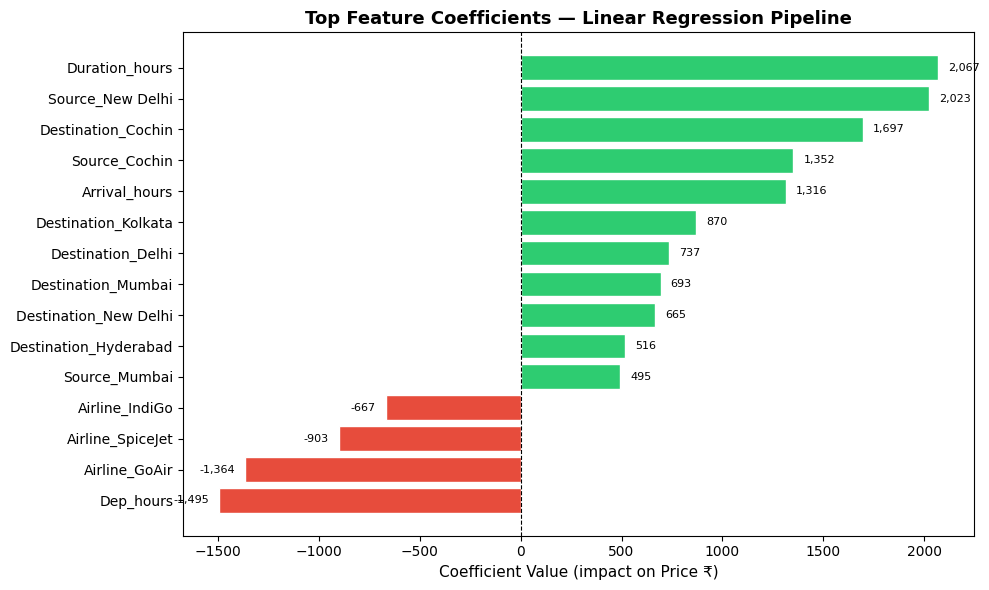

In [23]:
#Coefficient Plot
top_n = min(15, len(coef_df))
top_coef = coef_df.head(top_n).sort_values('Coefficient')

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_coef['Coefficient']]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Coefficient Value (impact on Price ₹)", fontsize=11)
plt.title("Top Feature Coefficients — Linear Regression Pipeline", fontsize=13, fontweight='bold')

for bar, val in zip(bars, top_coef['Coefficient']):
    plt.text(val + (50 if val >= 0 else -50), bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

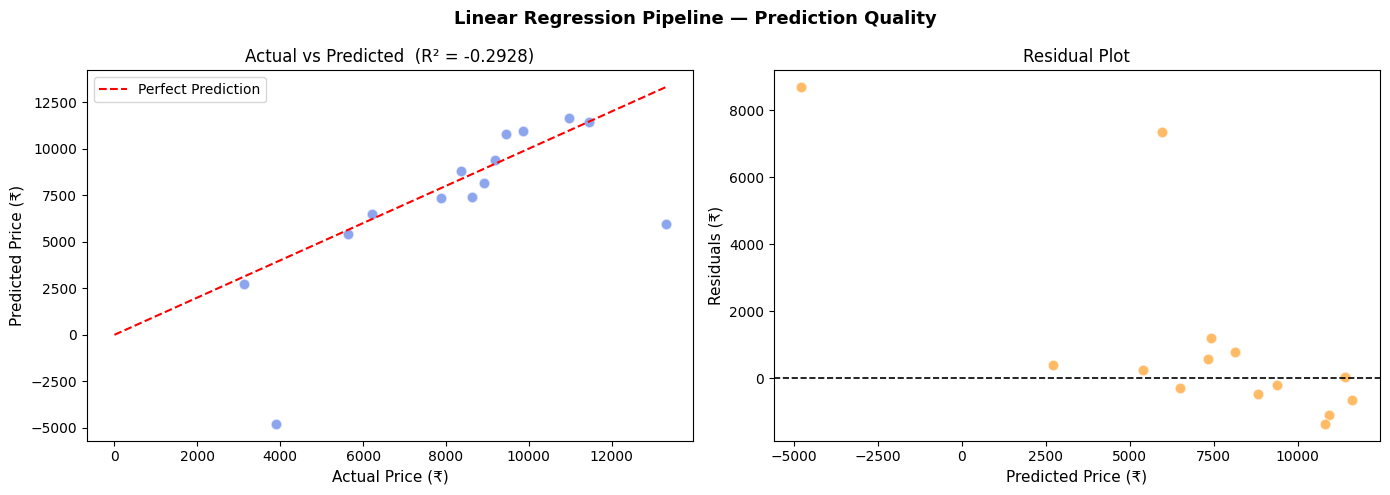

In [24]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Linear Regression Pipeline — Prediction Quality", fontsize=13, fontweight='bold')

# Scatter: Actual vs Predicted
max_val = max(y_test.max(), y_pred.max())
axes[0].scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolors='white', s=60)
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel("Actual Price (₹)", fontsize=11)
axes[0].set_ylabel("Predicted Price (₹)", fontsize=11)
axes[0].set_title(f"Actual vs Predicted  (R² = {r2:.4f})")
axes[0].legend()

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='white', s=60)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel("Predicted Price (₹)", fontsize=11)
axes[1].set_ylabel("Residuals (₹)", fontsize=11)
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.savefig('actual_vs_predicted_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
%%markdown
---
Prediction on dataset

---
Prediction on dataset


In [26]:
#Predict on a New Sample

new_flight = pd.DataFrame([{
    'Airline'        : 'IndiGo',
    'Source'         : 'Banglore',
    'Destination'    : 'New Delhi',
    'Total_Stops'    : 1,
    'Dep_hours'      : 9,
    'Dep_min'        : 25,
    'Arrival_hours'  : 12,
    'Arrival_min'    : 15,
    'Duration_hours' : 2,
    'Duration_min'   : 50,
}])

predicted_price = pipeline.predict(new_flight)[0]
print(f"✈️  Predicted Flight Price: ₹{predicted_price:,.2f}")

✈️  Predicted Flight Price: ₹4,753.43


In [27]:
##Alternate of randomforest
from xgboost import XGBRegressor

("regressor", XGBRegressor(n_estimators=300, learning_rate=0.05))

('regressor',
 XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...))

In [33]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error

# ── 1. Load fresh data ──────────────────────────────────────────
df_model = pd.read_csv('flight-price-analysis-and-prediction.csv')

# ── 2. Build Full_Date ──────────────────────────────────────────
df_model['Full_Date'] = pd.to_datetime(
    df_model['Year'].astype(str) + '-' +
    df_model['Month'].astype(str) + '-' +
    df_model['Date'].astype(str),
    errors='coerce'
)

# ── 3. Sort chronologically ─────────────────────────────────────
df_model = df_model.sort_values('Full_Date').reset_index(drop=True)

# ── 4. Encode categoricals ──────────────────────────────────────
for col in ['Airline', 'Source', 'Destination']:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# ── 5. Drop leaky features ──────────────────────────────────────
leaky_features = ['Arrival_hours', 'Arrival_min', 'Full_Date',
                  'Date', 'Month', 'Year']

X = df_model.drop(['Price'] + leaky_features, axis=1)
y = df_model['Price']

# ── 6. Temporal split (80% past → train, 20% future → test) ────
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Features: {list(X.columns)}")

# ── 7. Train model ──────────────────────────────────────────────
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ── 8. Evaluate ─────────────────────────────────────────────────
y_pred = model.predict(X_test)
print(f"\nR² Score : {r2_score(y_test, y_pred):.3f}")
print(f"MAE      : ₹{mean_absolute_error(y_test, y_pred):.0f}")

Train: 53 | Test: 14
Features: ['Airline', 'Source', 'Destination', 'Total_Stops', 'Dep_hours', 'Dep_min', 'Duration_hours', 'Duration_min']

R² Score : 0.919
MAE      : ₹701


In [28]:

import pickle

with open("flight_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [29]:

%%markdown
---
From here i can deploy the prediction code into VS-Code to web_app
---

---
From here i can deploy the prediction code into VS-Code to web_app
---
